In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
%cd /content/drive/MyDrive/Colab Notebooks/SW엔지니어

/content/drive/MyDrive/Colab Notebooks/SW엔지니어


In [10]:
%cd /content/drive/MyDrive/Colab Notebooks/SW엔지니어/data

/content/drive/MyDrive/Colab Notebooks/SW엔지니어/data


# 도시 소음 데이터
- 공식 사이트 (NYU Music and Audio Research Lab):
https://urbansounddataset.weebly.com/urbansound8k.html
- 10개 클래스 : 에어컨, 자동차 경적, 어린이 놀이, 개 짖는 소리 등
- 도시 소음의 8,732개(4초 이하)

In [ ]:
!wget https://zenodo.org/record/1203745/files/UrbanSound8K.tar.gz

--2025-06-24 00:15:07--  https://zenodo.org/record/1203745/files/UrbanSound8K.tar.gz
Resolving zenodo.org (zenodo.org)... 188.185.43.25, 188.185.48.194, 188.185.45.92, ...
Connecting to zenodo.org (zenodo.org)|188.185.43.25|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/1203745/files/UrbanSound8K.tar.gz [following]
--2025-06-24 00:15:08--  https://zenodo.org/records/1203745/files/UrbanSound8K.tar.gz
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 6023741708 (5.6G) [application/octet-stream]
Saving to: ‘UrbanSound8K.tar.gz.1’

UrbanSound8K.tar.gz   0%[                    ]  28.88M   430KB/s    eta 3h 37m ^C


In [ ]:
!mkdir -p /UrbanSound8K
!tar -xvzf UrbanSound8K.tar.gz UrbanSound8K/audio/fold1/ UrbanSound8K/audio/fold2/ UrbanSound8K/audio/fold3/ -C /UrbanSound8K

UrbanSound8K/audio/fold1/
UrbanSound8K/audio/fold1/.DS_Store
^C


In [1]:
import os
import glob
# glob : 파일 시스템에서 패턴 매칭을 사용해 파일 목록을 찾는 라이브러리
import librosa
# 음악 또는 오디오 처리를 위한 라이브러리
import numpy as np

# 도시 소음 소리의 특징과 정답(label) 추출
1. 각 소리 파일을 일정한 길이로 나눔 -> 슬라이딩 윈도우
2. 각 구간 MFCC 추출
3. 파일 이름으로 부터 label 추출
4. 특징과 라벨 리스트 변환

In [2]:
# 윈도우 구간을 만들어주는 generater 함수 생성

# data_length : 전체 데이터 길이
# window_size : 자를 구간의 크기
# step_size : 윈도우를 얼만큼 이동할지
def generate_windows (data_length, window_size, step_size ):
  for start in range(0, data_length - window_size + 1 , step_size):
    yield start, start + window_size
    # yield : 제너레이터 함수를 만들기 위해 사용

## MFCC(Mel-Frequency Cepstral Cofficients)
- 오디오 신로를 사람이 듣는 방식과 유사하게 표현한 주파수 기반 특징
- 주로 음성 인식, 환경 소리 분류 등에서 사용
- Mel : 사람의 달팽이관을 모티브로 따온 값
  - 달팽이관의 부분마다 다른 주파수(진동수)를 감지
  - 저주파 -> 고주파 영역으로 갈수록 얇아짐
  - 주파수 낮으면 소리 변화 잘 감지, 높으면 감지하기 어려움


### MFCC 동작 방식
- 1. 프레임 분할
  - 짧은 구간으로 나눔 (일반적 20~40ms)
- 2 STFT (Shprt-time Fourier Transform)
  - 각 구간 별 푸리에 변환 수행하여 주파수 스팩트럼
  - 푸리에 변환 : 시간영역의 신호 주파수 영역으로 분해하는 방법
- 3. med Filter Bank 적용
  - 사람의 청각 특성을 반영하여 단순 주파수 값보다 더욱 사람처럼 소리를 인식할 수 있도록함.
  - 낮은 주파수는 좁은, 높은 주파수는 넓은 필터 배치
- 4. 로그 스케일링 (Log Scaling)
  - 멜 스팩트럼의 진폭 값에 로그 변환
- 5.Dct(Discrete Cosine Transform)
  - 특징을 압축해서 표현

In [3]:
# 2. 하나의 오디오 파일에서 MFCC 특징 추출

def extract_mfcc_segments(audio, sr, bands = 20, frames=41):
  # 윈도우 설정
  window_size = 512*(frames - 1)
  step_size = window_size // 2
  mfcc_segments = []

  # 오디오를 슬라이딩 윈도우로 자름
  for start, end in generate_windows (len(audio), window_size, step_size):
    segment = audio[start:end]

    # MFCC 특징 추출
    # sr : 샘플링레이트 (초당 샘플링 횟수)
    # band : MFCC 계수 개수 (기본 20), 한 프레임당 20개 숫자로 그 순간 주파수 특징 표현
    mfcc = librosa.feature.mfcc(y=segment, sr=sr, n_mfcc=bands)
    mfcc = mfcc.T # (time, bands)

    # 프레임 수 유지
    if mfcc.shape[0] == frames:  # 정확히 원하는 프레임 수 일 때
      mfcc_segments.append(mfcc)
  return np.array(mfcc_segments) # shape : (segments, frames, bands)
  # 하나의 소리(오디오)에서 짧은 구간 여러개 추출 후 각 구간에서 MFCC를 뽑아(frames, bands) 저장

In [4]:
# MFC 시각화
import librosa.display
import matplotlib.pyplot as plt

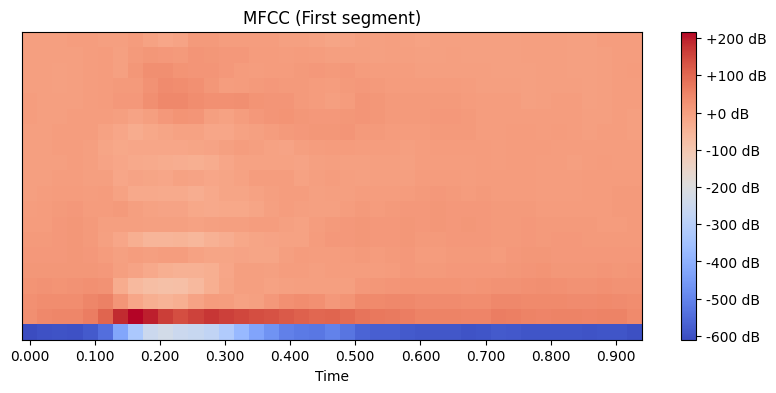

In [11]:
# 오디오 파일 하나 가져오기
audio, sr = librosa.load('./UrbanSound8K/audio/fold1/101415-3-0-2.wav')

#MFCC 추출
mfcc_segments =extract_mfcc_segments(audio, sr)
 # 시각화
plt.figure(figsize=(10,4))
librosa.display.specshow(mfcc_segments[0].T, sr=sr, x_axis='time')
plt.colorbar(format='%+2.0f dB')
plt.title('MFCC (First segment)')
plt.show()

In [12]:
# 3. 파일 이름에서 라벨 추출 (UrbanSoundBK 기준)
# 7061-6-0-0.mav -> file_name-label(class)-...wav
def get_label_from_filename(filename):
  parts = filename.split('/') # 경로를 가져와서 '/' 기준 쪼개기
  basename = os.path.basename(parts[-1]) # 쪼개진 문자열이 담긴 리스트에서 -1번째 인덱스가 파일명
  label = int(basename.split('-')[1])
  return label

In [13]:
  # 4. 전체 폴더에서 특징과 라벨 추출
  # 폴더 내 모든 오디오 데이터로부터 features, labels 리스트 생성
  def extract_features_from_folder(folder_path, file_ext='*.wav',bands = 20, frames=41):
    all_features = []
    all_labels = []

    # glob함수 : 사용자가 제시한 조건에 맞는 파일명을 리스트 형식으로 반환

    for filepath in glob.glob(os.path.join(folder_path, file_ext)):
      try:
        audio, sr = librosa.load(filepath, sr=None)
        # 오디오 자르고 MFCC 추출(이전에 만든 함수 사용)
        # 결과 : (segment 수, frames, bands)
        mfccs = extract_mfcc_segments(audio, sr, bands, frames)
        # 파일 이름에서 라벨 추출
        label = get_label_from_filename(filepath)

        if mfccs.shape[0] > 0:
          all_features.append(mfccs)
          all_labels.append([label] * len(mfccs))
      except Exception as e:
        print(f'오류 발생: {filepath}, 에러 : {e}')
    return all_features, all_labels

In [18]:
all_features = []
all_labels = []

folds = ['fold1','fold2','fold3']

for fold in folds:
  folder_path = os.path.join('UrbanSound8K/audio', fold)
  features, labels = extract_features_from_folder(folder_path)
  all_features.extend(features)
  all_labels.extend(labels)

# numpy 배열로 변환
x = np.concatenate(all_features, axis=0).astype(np.float32)
y = np.concatenate(all_labels, axis=0).astype(np.int32)

In [19]:
for fold in folds:
    folder_path = os.path.join('UrbanSound8K/audio', fold)
    print(f"폴더 경로: {folder_path}")
    features, labels = extract_features_from_folder(folder_path)
    print(f"{fold}에서 추출한 feature 수: {len(features)}")
    print(f"{fold}에서 추출한 label 수: {len(labels)}")
    all_features.extend(features)
    all_labels.extend(labels)

print(f"전체 features 개수: {len(all_features)}")
print(f"전체 labels 개수: {len(all_labels)}")


폴더 경로: UrbanSound8K/audio/fold1
fold1에서 추출한 feature 수: 856
fold1에서 추출한 label 수: 856
폴더 경로: UrbanSound8K/audio/fold2
fold2에서 추출한 feature 수: 865
fold2에서 추출한 label 수: 865
폴더 경로: UrbanSound8K/audio/fold3
fold3에서 추출한 feature 수: 908
fold3에서 추출한 label 수: 908
전체 features 개수: 5258
전체 labels 개수: 5258


In [16]:
from sklearn.model_selection import train_test_split

In [21]:
# 문제와 답 나누기
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [22]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((32963, 41, 20), (8241, 41, 20), (32963,), (8241,))

## 모델링
- GRU 기반 순환 신경망

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, InputLayer
from tensorflow.keras.optimizers import Adam

In [26]:
from threading import active_count
model = Sequential()

# 입력층
model.add(InputLayer(input_shape=(41,20))) # (frams 수(순환 횟수),bands(특성 수))
model.add(GRU(128,activation='tanh'))
model.add(Dense(128, activation='relu'))

# 출력층
model.add(Dense(10,activation='softmax')) # 다중분류
# 도시 소음 10가지 클래스 분류 문제

# 모델 학습 설정
model.compile(
    optimizer = Adam(1e-4),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [27]:
# 모델 학습
model.fit(X_train, y_train, epochs=20, batch_size=24, validation_split=0.1)

Epoch 1/20
1237/1237 ━━━━━━━━━━━━━━━━━━━━ 58s 44ms/step - accuracy: 0.4245 - loss: 1.7774 - val_accuracy: 0.6433 - val_loss: 1.0984
Epoch 2/20
1237/1237 ━━━━━━━━━━━━━━━━━━━━ 83s 45ms/step - accuracy: 0.6922 - loss: 0.9932 - val_accuracy: 0.7404 - val_loss: 0.8103
Epoch 3/20
1237/1237 ━━━━━━━━━━━━━━━━━━━━ 81s 44ms/step - accuracy: 0.7693 - loss: 0.7411 - val_accuracy: 0.7862 - val_loss: 0.6544
Epoch 4/20
1237/1237 ━━━━━━━━━━━━━━━━━━━━ 84s 46ms/step - accuracy: 0.8152 - loss: 0.5964 - val_accuracy: 0.8207 - val_loss: 0.5519
Epoch 5/20
1237/1237 ━━━━━━━━━━━━━━━━━━━━ 77s 42ms/step - accuracy: 0.8483 - loss: 0.4951 - val_accuracy: 0.8465 - val_loss: 0.4834
Epoch 6/20
1237/1237 ━━━━━━━━━━━━━━━━━━━━ 59s 48ms/step - accuracy: 0.8650 - loss: 0.4360 - val_accuracy: 0.8641 - val_loss: 0.4326
Epoch 7/20
1237/1237 ━━━━━━━━━━━━━━━━━━━━ 53s 43ms/step - accuracy: 0.8828 - loss: 0.3831 - val_accuracy: 0.8678 - val_loss: 0.4046
Epoch 8/20
1237/1237 ━━━━━━━━━━━━━━━━━━━━ 54s 44ms/step - accuracy: 0.8971 -

In [ ]:
# 시각화
import matplotlib.pyplot as plt
plt.figure(figsize = (10,5))
plt.plot(his_rnn.history['accuracy'], label = 'train_acc')
plt.plot(his_rnn.history['val_accuracy'], label = 'val_acc')
plt.legend()
plt.show()

In [28]:
# 예측 및 평가
from sklearn.metrics import accuracy_score
import numpy as np

In [31]:
y_pre = model.predict(X_test) # 10개의 확률값(클래스마다)
y_pre_labels = np.argmax(y_pre, axis=1) # 확률이 가장 높은 값을 이용해 라벨값만 담기

258/258 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step


In [34]:
acc = accuracy_score(y_test, y_pre_labels)
print(f'Test Accuracy : {acc:.4f}')

Test Accuracy : 0.9319
